<center><h1><b>LABORATORY 5</b></h1></center>

---

In [5]:
library(coda)
library(viridis)
library(plotrix)
library(rjags)

# Exercise 1: Sampling Gaussian Mixture
Let $g(x, \mu, \sigma)$ be the un-normalized distribution of a weighted mixture of two Gaussian distributions:

$$
g(\theta \mid x) = \sum_{i=1}^{2} \phi_i \, \mathcal{N}(\mu_i, \sigma_i)
$$

where the parameters are given by:

$$
\phi_0 = 0.6, \quad \phi_1 = 0.4
$$

$$
\mu = \{-3, 3\}, \quad \sigma = \{1, 1\}
$$


#### 1. Draw a Markov Chain from the posterior distribution using a Metropolis-Hastings algorithm, usings a Norm (0, 1) as random-walk candidate density

When the proposal ditribution si simmetric, the metropolis-hastings algoirthm reduce itself to the metropolis one.

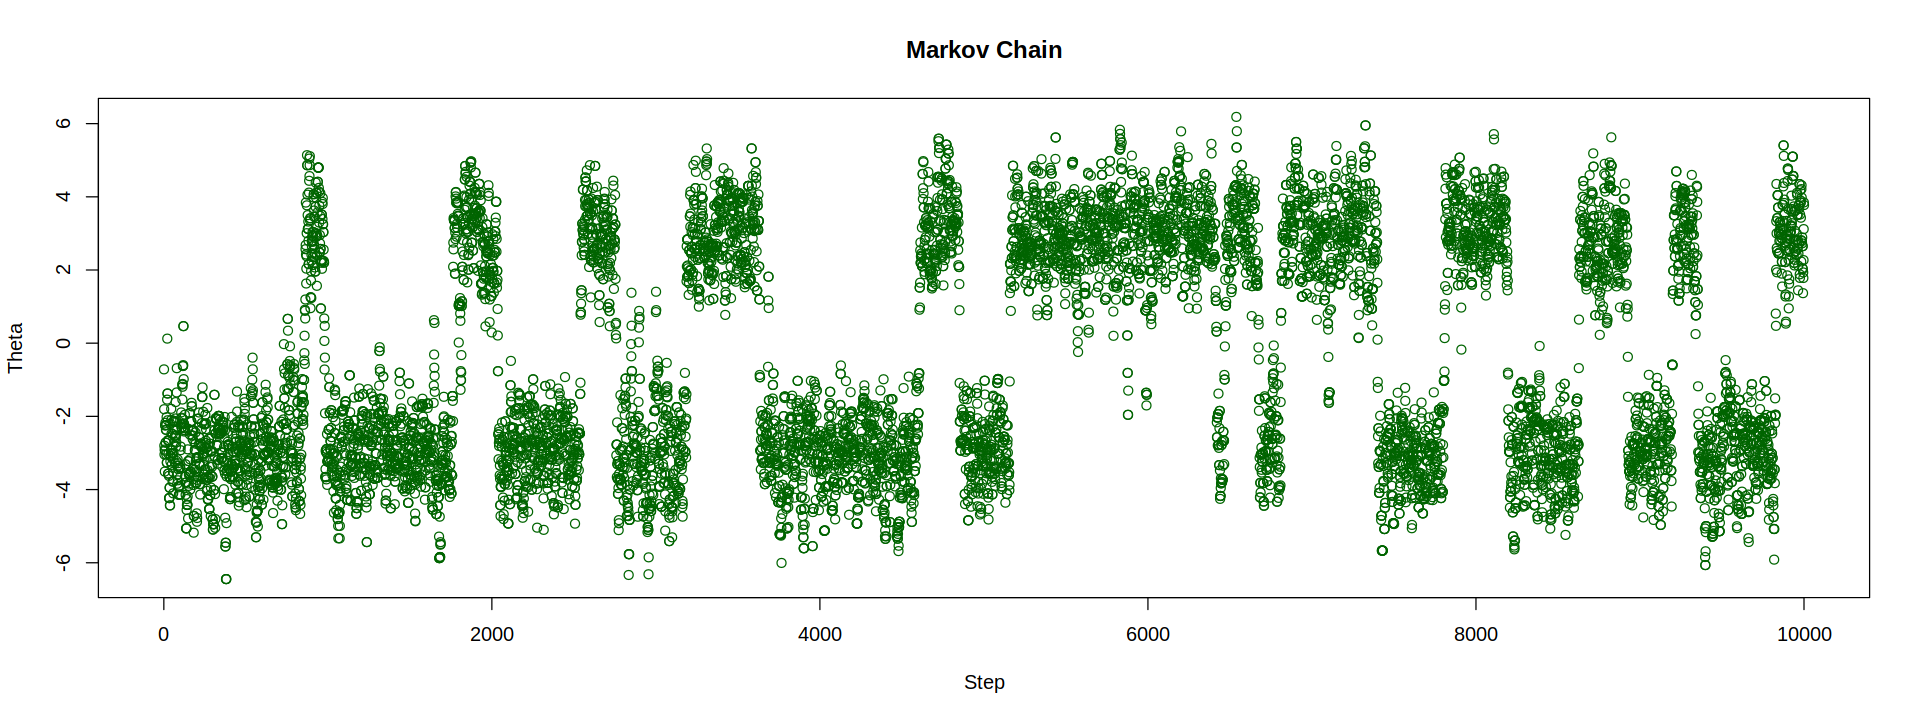

In [2]:
# PDF as mixture of two Gaussians
target_pdf <- function(theta) {
    phi0 <- 0.6
    phi1 <- 0.4
    mu <- c(-3, 3)
    sigma <- c(1, 1)
    return ( phi0 * dnorm(theta, mean = mu[1], sd = sigma[1]) + phi1 * dnorm(theta, mean = mu[2], sd = sigma[2]) )
}

# METROPOLIS mcmc (using the logarithm):
metropolis <- function(pdf, x_start, n, sigma) {
    # initialization:
    samples <- numeric(n)               # vettore numerico con dentro n zeri
    x_old <- x_start
    x_old_log <- log10( pdf(x_old) )
    # n iterazioni dell'algoritmo:
    for (i in 1:n) {
        x_new <- rnorm(1, x_old, sigma)         # pesco un numero da una gaussiana centrata nel x_old precedente
        x_new_log <- log10( pdf(x_new) )        # e ne calcolo il logaritmo della pdf
        log_rho <- x_new_log - x_old_log
        if (log_rho > 0 || log10(runif(1)) < (log_rho)) {   # '||' = or
            x_old <- x_new
            x_old_log <- x_new_log
        }
        samples[i] <- x_old    # aggiungo ai samples il numero (che sia quello nuovo se accettato o quello vecchio se quello nuovo è rigettato)
    } 
    return(samples)
}

# Draw 10000 samples with starting point 0 and proposal std 1
n_steps <- 10000
samples <- metropolis(pdf = target_pdf, x_start = 0, n = n_steps, sigma = 1)

# PLOT of the chain:
options(repr.plot.width = 16, repr.plot.height = 6)
plot(samples, main='Markov Chain', xlab='Step', ylab='Theta', col='darkgreen')


#### 2. Plot the sampled distribution

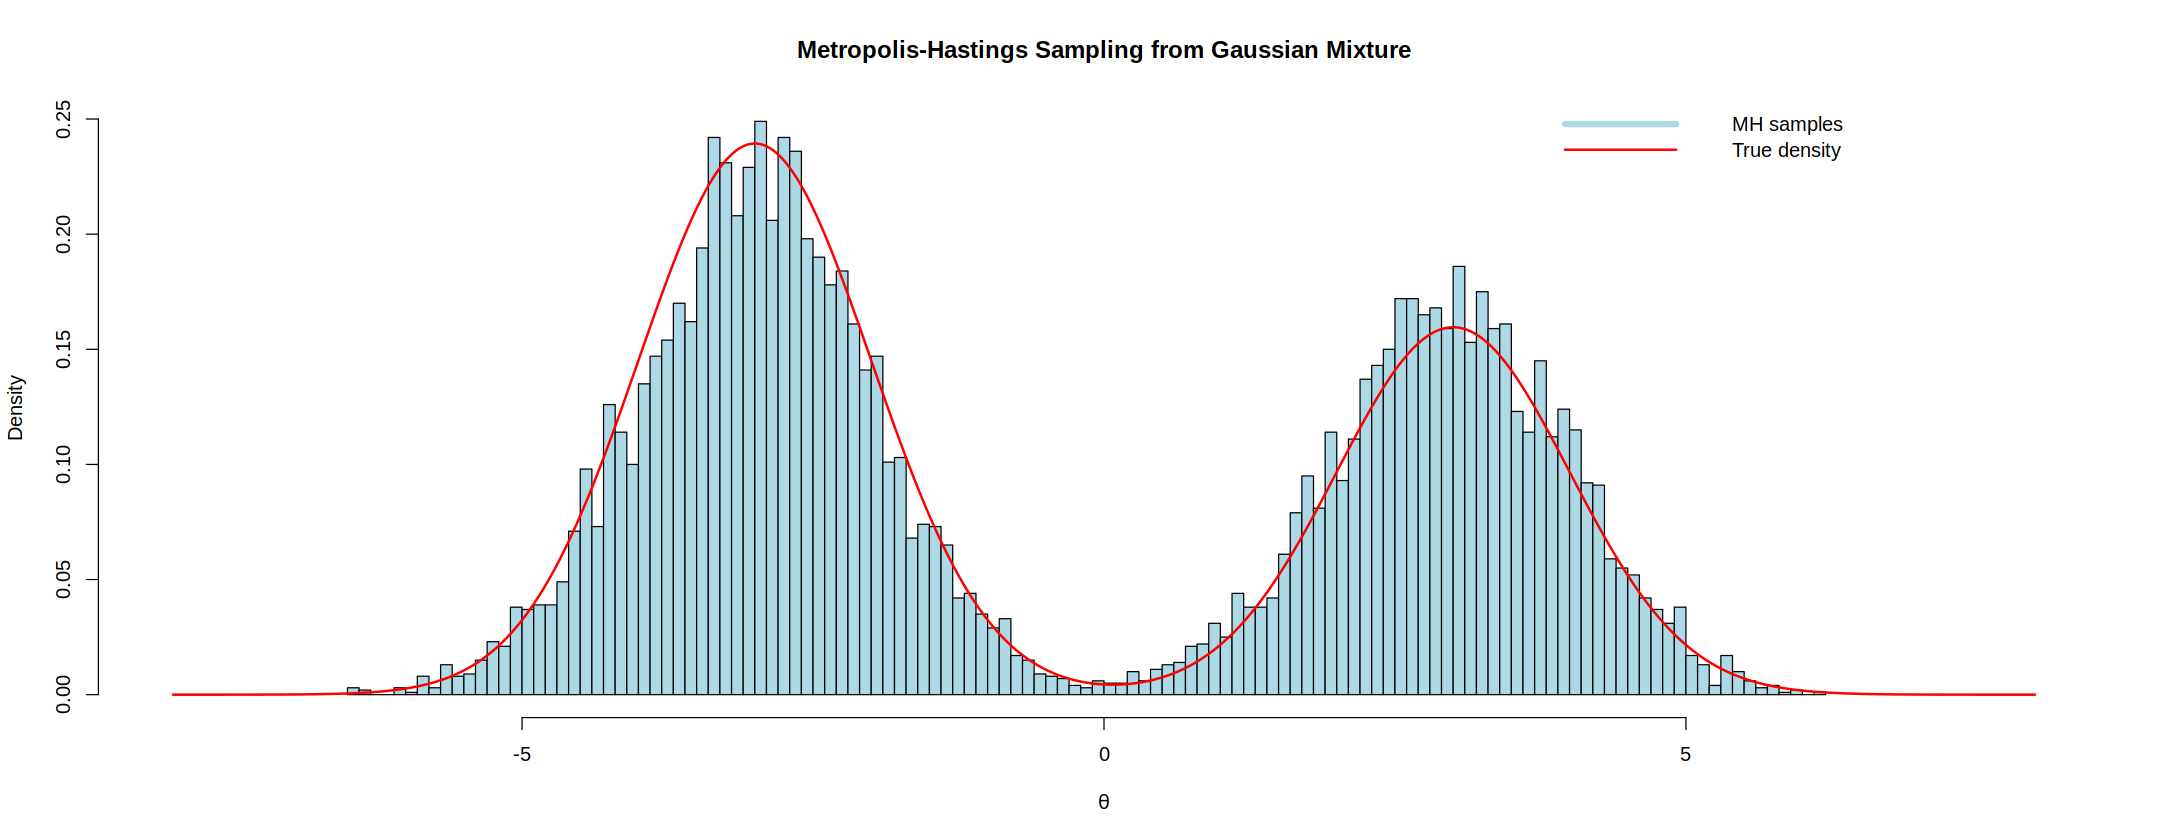

In [3]:
# Plot histogram with true density
options(repr.plot.width = 18, repr.plot.height = 7)
hist(samples, breaks = 100, freq = FALSE, col = "lightblue",
     main = "Metropolis-Hastings Sampling from Gaussian Mixture",
     xlab = expression(theta), xlim = c(-8, 8))

curve(0.6 * dnorm(x, -3, 1) + 0.4 * dnorm(x, 3, 1),
      from = -8, to = 8, n = 1000, col = "red", lwd = 2, add = TRUE)

legend("topright", legend = c("MH samples", "True density"),
       col = c("lightblue", "red"), lwd = c(5, 2), bty = "n")

#### 3. Evaluate the mean and the variance

In [4]:
# Calcolo della media dei campioni
mean_sample <- mean(samples)

# Calcolo della varianza dei campioni
var_sample <- var(samples)

# Stampa dei risultati
cat("Media campionaria:", mean_sample, "\n")
cat("Varianza campionaria:", var_sample, "\n")


Media campionaria: -0.3921825 
Varianza campionaria: 9.747147 


#### 4. Analyze the chain with the CODA package and plot the chain autocorrelation


Iterations = 1:10000
Thinning interval = 1 
Number of chains = 1 
Sample size per chain = 10000 

1. Empirical mean and standard deviation for each variable,
   plus standard error of the mean:

          Mean             SD       Naive SE Time-series SE 
      -0.39218        3.12204        0.03122        0.53755 

2. Quantiles for each variable:

  2.5%    25%    50%    75%  97.5% 
-4.725 -3.117 -1.797  2.783  4.552 


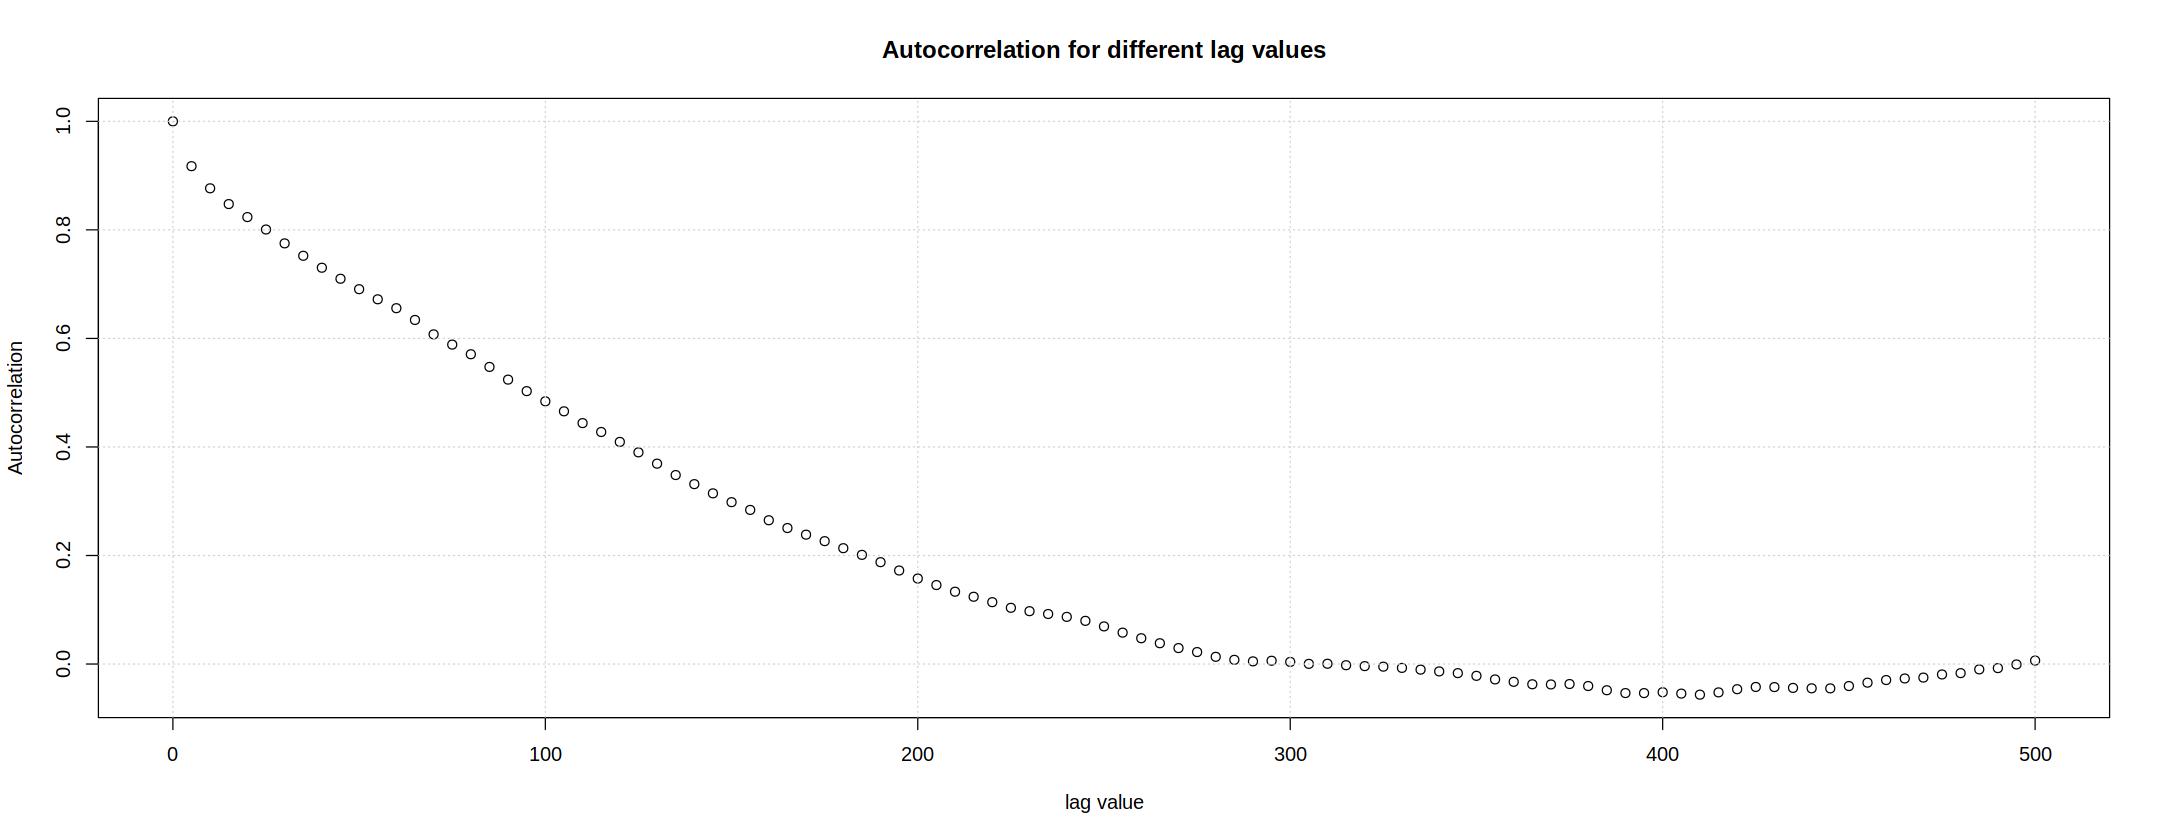

In [5]:
# let's transorm in a mcmc object first:
chain <- mcmc(samples)
summary(chain)

# analysis:
my_lags <- seq(0,500,5)                # multiple value for the lag parameter
y <- autocorr( chain, lags=my_lags )    # vector of autocorrelation values, one for each lag

# PLOT:
options(repr.plot.width = 18, repr.plot.height = 7)
plot(my_lags, y, xlab='lag value', ylab='Autocorrelation', main='Autocorrelation for different lag values') 
grid()

#### 5. Try different burn-in cycles and thinning, plot the related posterior distribution and the chain autocorrelation function. What are the best parameters ?

We wil work with:
* Burn-in: Number of initial samples to discard (to let the chain stabilize).
* Thinning: Keep only every k-th sample (to reduce autocorrelation).

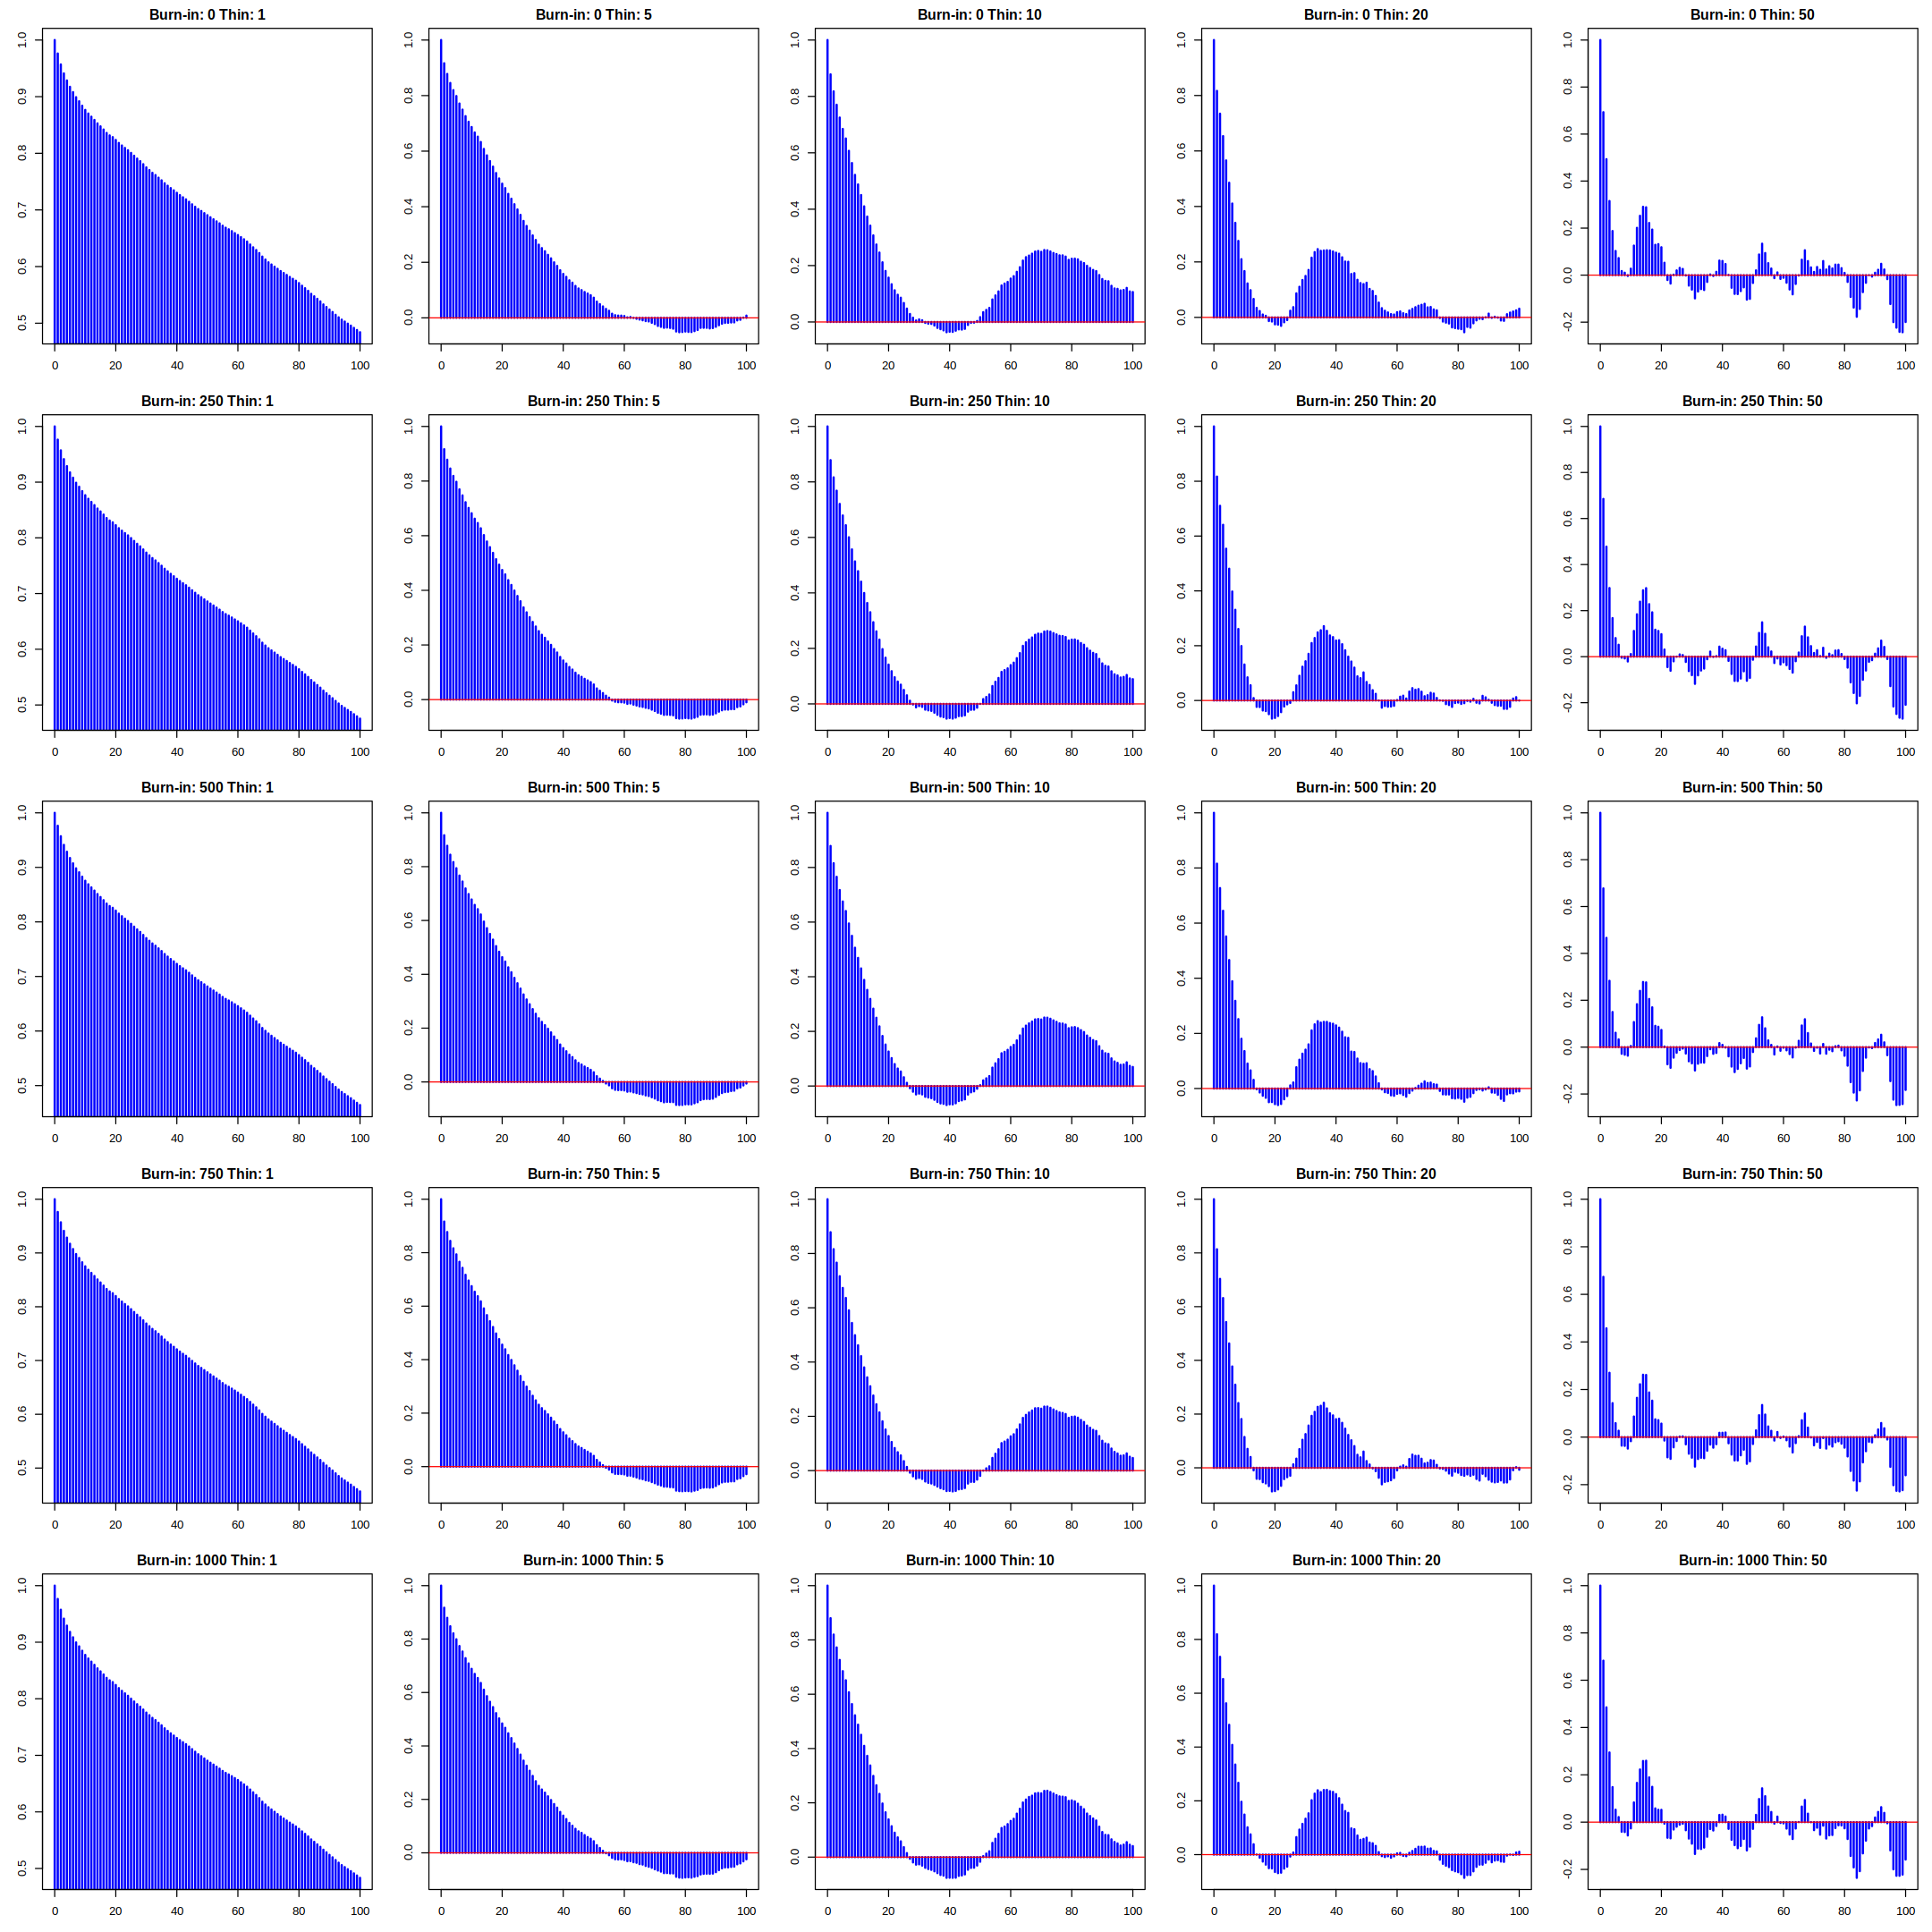

In [42]:
burnin_values <- seq(0, 1000, 250)
thin_values <- c(1, 5, 10, 20, 50)

# Set up the plotting layout (5 rows x 5 columns, enough for 11x5=55 plots)
options(repr.plot.width = 18, repr.plot.height = 18)
par(mfrow = c(length(burnin_values), length(thin_values)), mar = c(3, 3, 2, 1))

# cycle over pairs of parameters values:
for (burn in burnin_values) {
  for (thin in thin_values) {
    
    # Burn-in and thinning
    chain <- samples[(burn + 1):length(samples)]
    thinned_chain <- chain[seq(1, length(chain), by = thin)]
    mcmc_chain <- mcmc(thinned_chain)
    
    # Compute autocorrelation function for lags 0 to length(chain)-1
    acf_res <- autocorr(mcmc_chain, lags = 0:100 )
    
    # Plot ACF:
    plot(0:(length(acf_res) - 1), acf_res, type = "h", lwd = 2, col = "blue",
         xlab = "Lag", ylab = "Autocorrelation",
         main = paste("Burn-in:", burn, "Thin:", thin))
    abline(h = 0, col = "red")
  }
}


---

# Exercise 2: Gaussian model
Let
$$ x = \{13.427, 8.588, 10.908, 11.582, 11.011, 9.735, 13.779, 9.763\} $$
be $ n = 8 $ observed data from a Gaussian distribution with unknown mean $m$ and variance $s^2$.

Assuming a uniform prior distributions for the parameters:
*  m ∼ dunif(-10,30)
*  s ∼ dnorm(0, 50)

#### 1. Build a simple JAGS model and run a Markov Chain Monte Carlo to obtain the posterior distribution of the mean and variance.


Iterations = 2001:12000
Thinning interval = 1 
Number of chains = 1 
Sample size per chain = 10000 

1. Empirical mean and standard deviation for each variable,
   plus standard error of the mean:

            Mean     SD Naive SE Time-series SE
m_over_s 14.1718 1.2550 0.012550      0.0158653
mu       11.1036 0.2800 0.002800      0.0034676
sigma     0.7892 0.0673 0.000673      0.0008159

2. Quantiles for each variable:

            2.5%     25%     50%     75%   97.5%
m_over_s 11.9059 13.2865 14.1291 14.9843 16.7450
mu       10.5556 10.9174 11.0995 11.2915 11.6530
sigma     0.6647  0.7421  0.7869  0.8337  0.9279


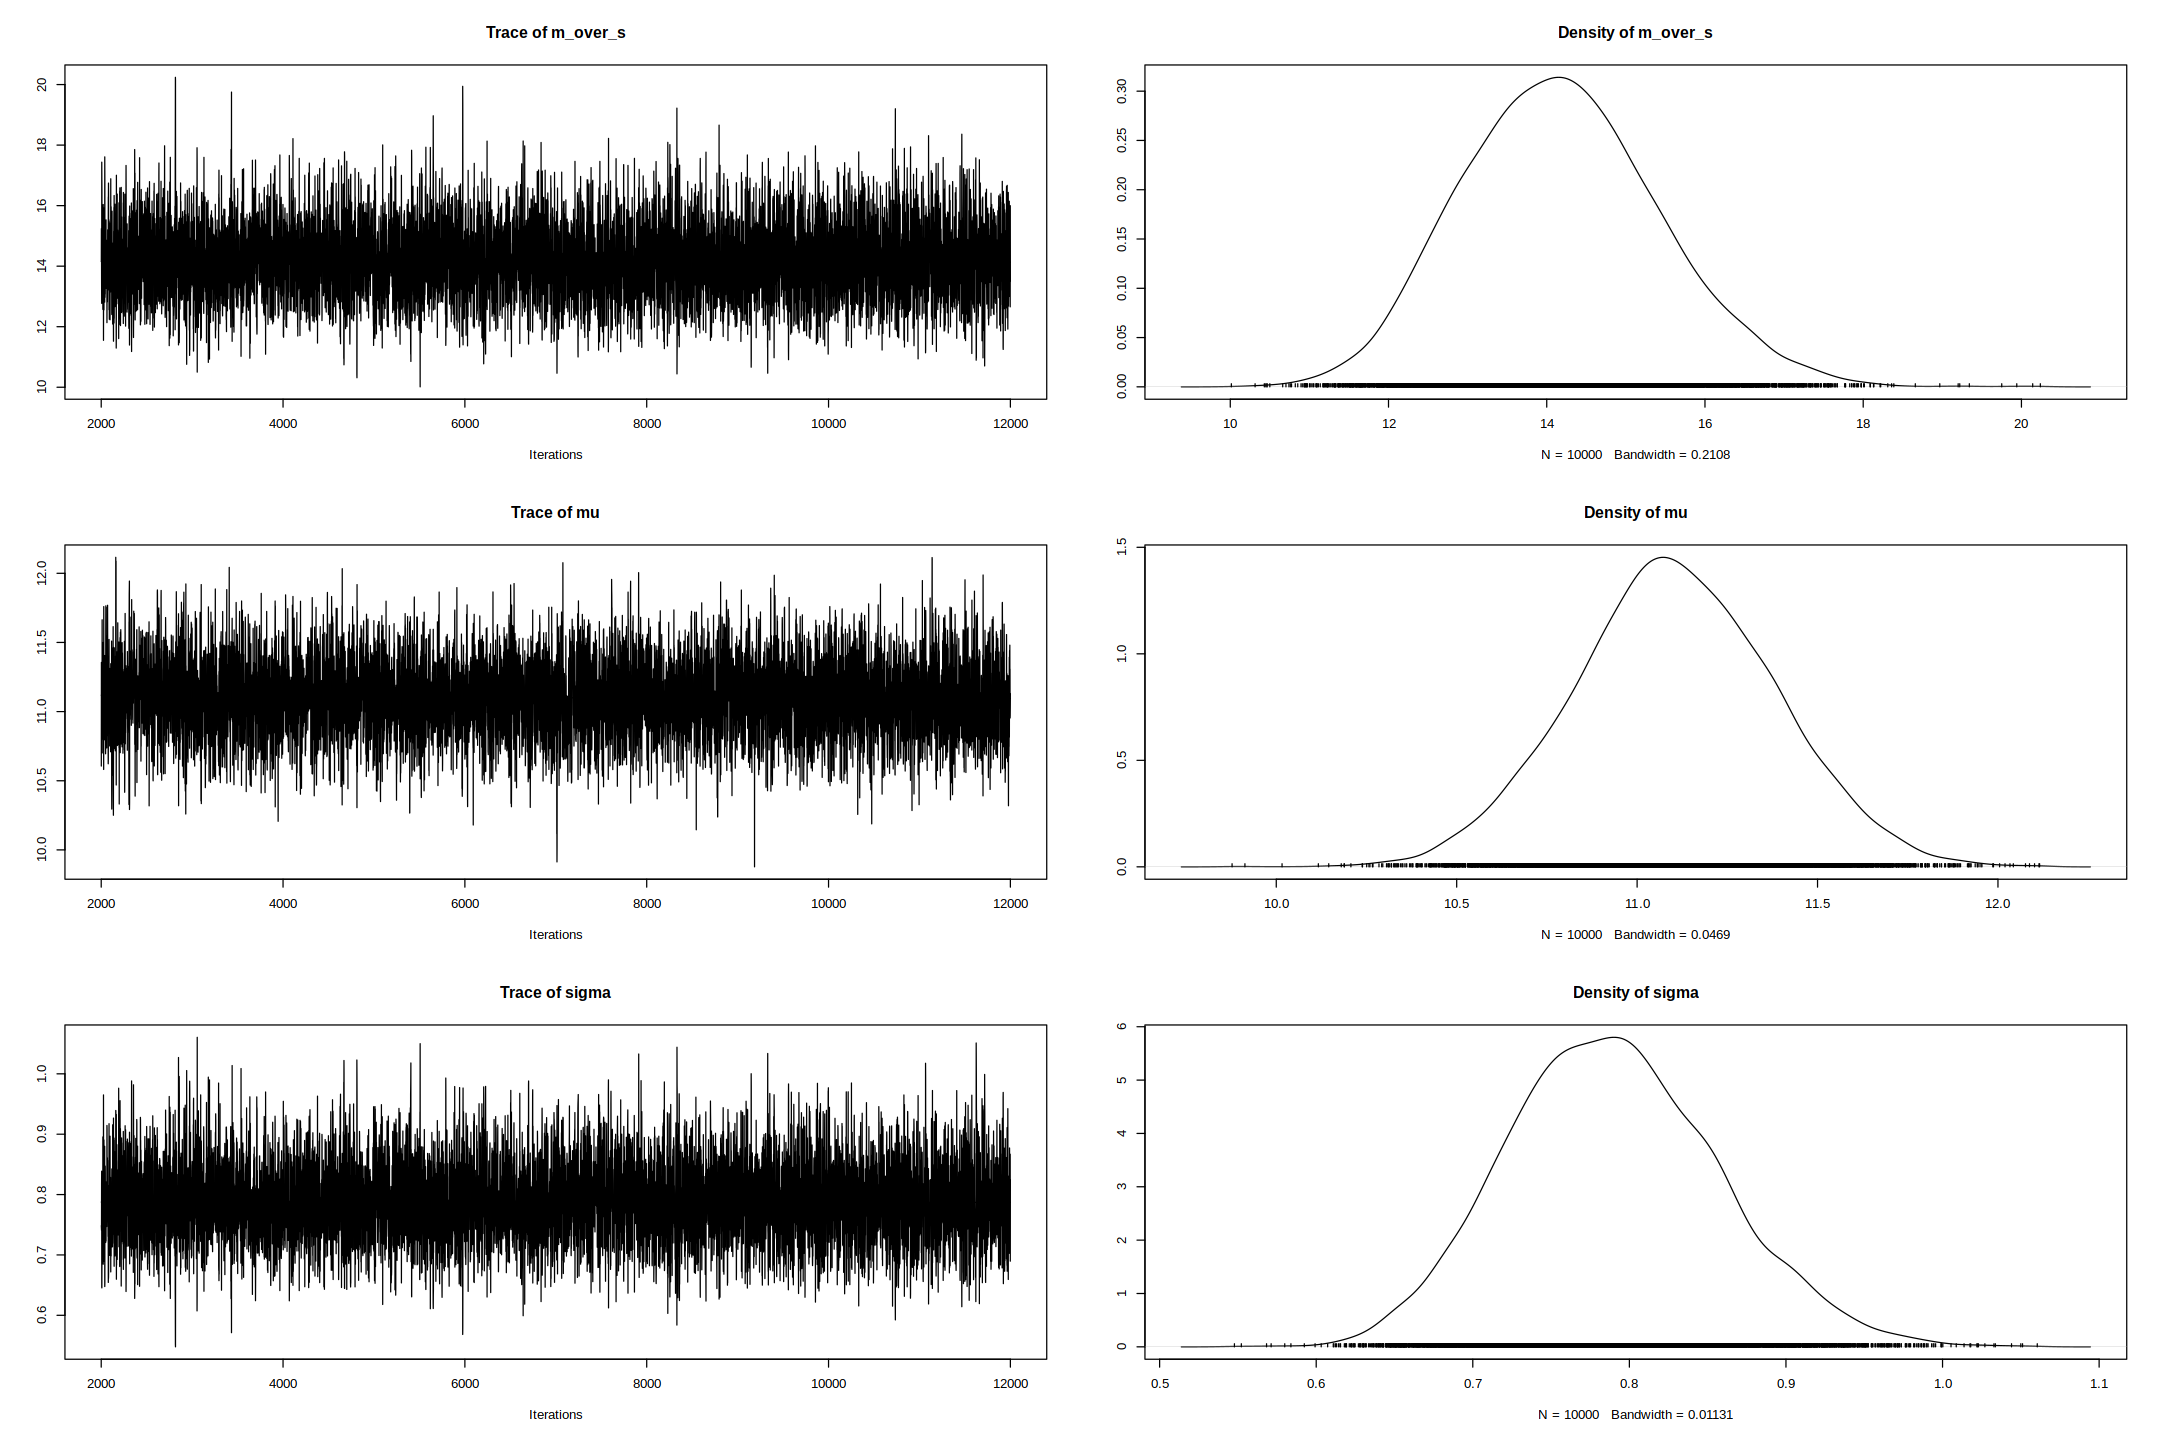

In [22]:
# DATA:
x <- c(13.427, 8.588, 10.908, 11.582, 11.011, 9.735, 13.779, 9.763)

# JAGS model:
model_string <- "
model {
    for (i in 1:length(X)) {
        X[i] ~ dnorm(mu, tau)
    }
    mu ~ dunif(-10, 30)
    tau <- 1 / (sigma * sigma) 
    sigma ~ dnorm(0, 50) T(0,)
    
    m_over_s <- mu / sigma
}
"
writeLines(model_string, "gaussian_model.bug")

# Prepare data for JAGS
data <- list(X = x)

# Initialize and run JAGS
jags_model <- jags.model("gaussian_model.bug", data = data, quiet = TRUE)
update(jags_model, 1000)    # burn-in

# Sample from posterior:
chain <- coda.samples(jags_model, variable.names = c("mu", "sigma", "m_over_s"), n.iter = 10000)

# Print summary and PLOT:
summary(chain)
options(repr.plot.width = 18, repr.plot.height = 12)
plot(chain)


#### 2. Compute the posterior distribution for m/s

Posterior mean of m/s: 14.1718 
Posterior standard deviation of m/s: 1.255021 


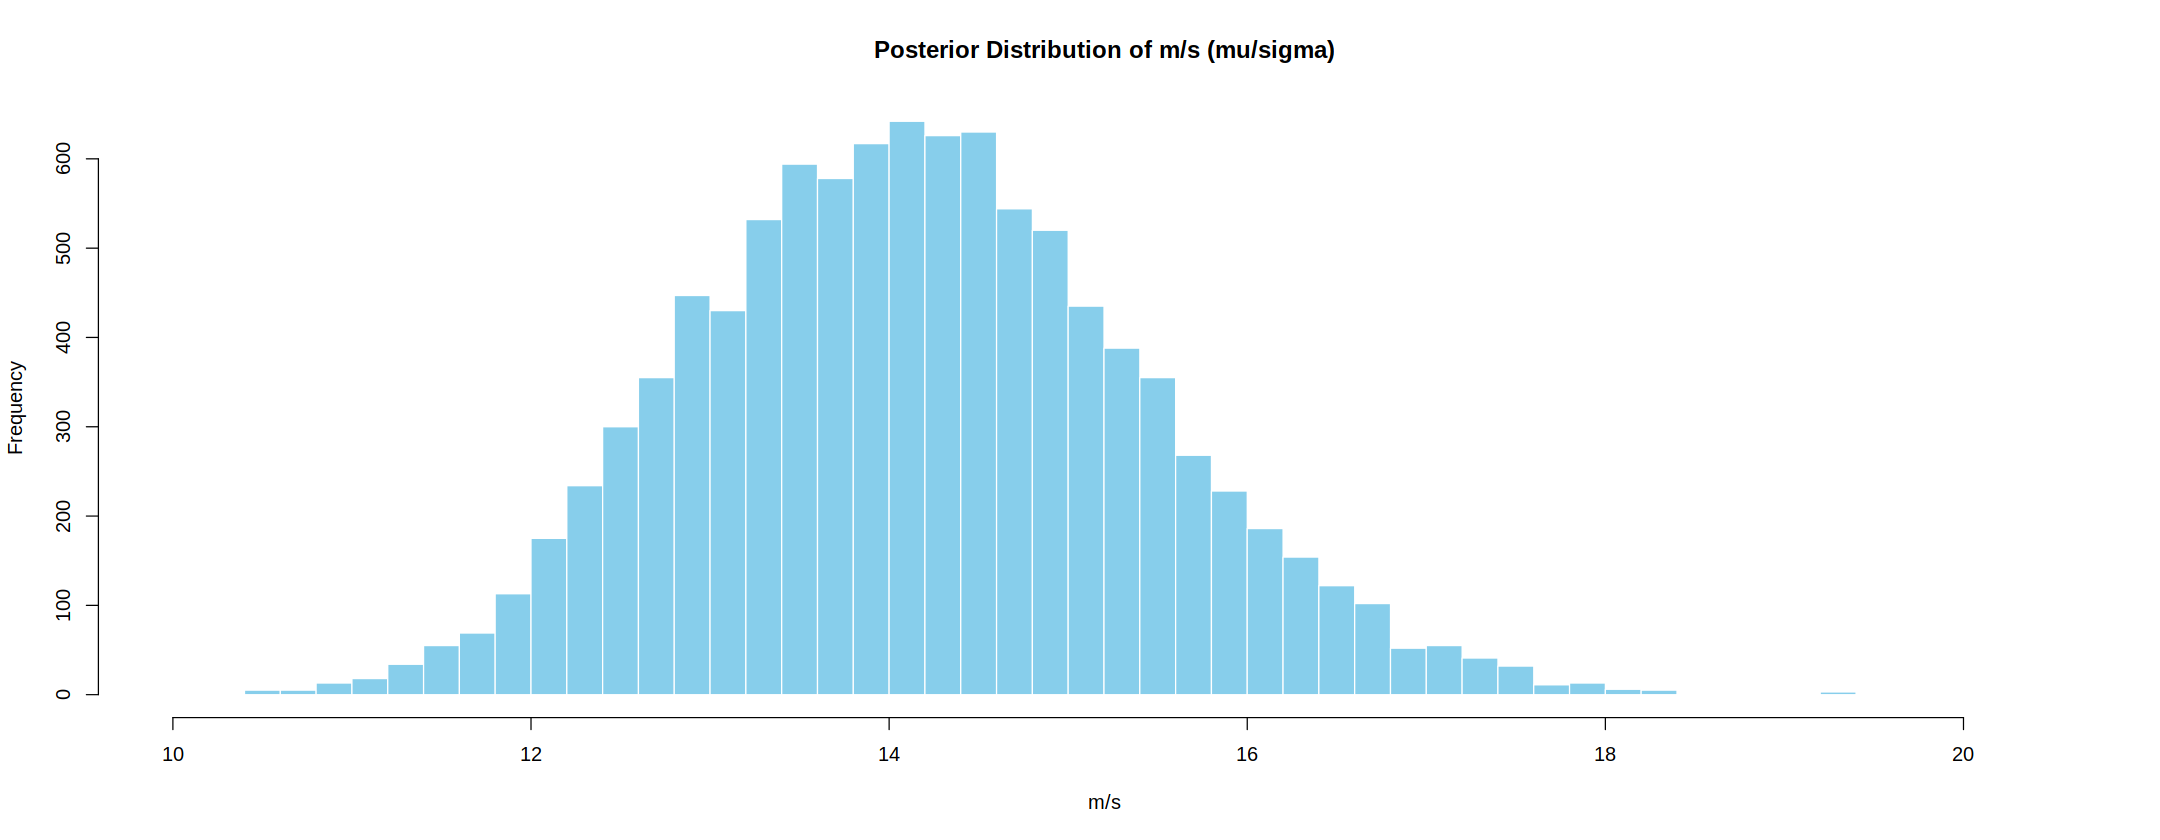

In [23]:
# samples for all variables
samples_matrix <- as.matrix(chain)
ratio_samples <- samples_matrix[, "m_over_s"]   # extract the 'ratio' column

# Plot the posterior distribution
options(repr.plot.width = 18, repr.plot.height = 7)
hist(ratio_samples,
     breaks = 50,
     col = "skyblue",
     border = "white",
     main = "Posterior Distribution of m/s (mu/sigma)",
     xlab = "m/s")

# Compute summary statistics
posterior_mean <- mean(ratio_samples)
posterior_sd <- sd(ratio_samples)

# Print results
cat("Posterior mean of m/s:", posterior_mean, "\n")
cat("Posterior standard deviation of m/s:", posterior_sd, "\n")


---

# Exercise 3 : Power Law fitting

#### 1. Using R, generate 100 synthetic data from power law distribution:

$$p(x | \alpha, x_{min}) = \frac{\alpha-1}{x_{min}} \left( \frac{x}{x_{min}} \right)^{-\alpha}, \quad x \ge x_{min}$$

with fixed $x_{min} = 10$ and power law exponent $\alpha = 2.5$

To do it, we can use the inverse CDF method, with $z$ uniform in $[0,1]$:
$$ CDF = 1 - x_{min}^{\alpha-1}x^{1-\alpha} := z $$
$$ \text{inverting:} \quad x(z) = \left( \frac{1-z}{ x_{min}^{\alpha -1} } \right)^{1-\alpha}  $$

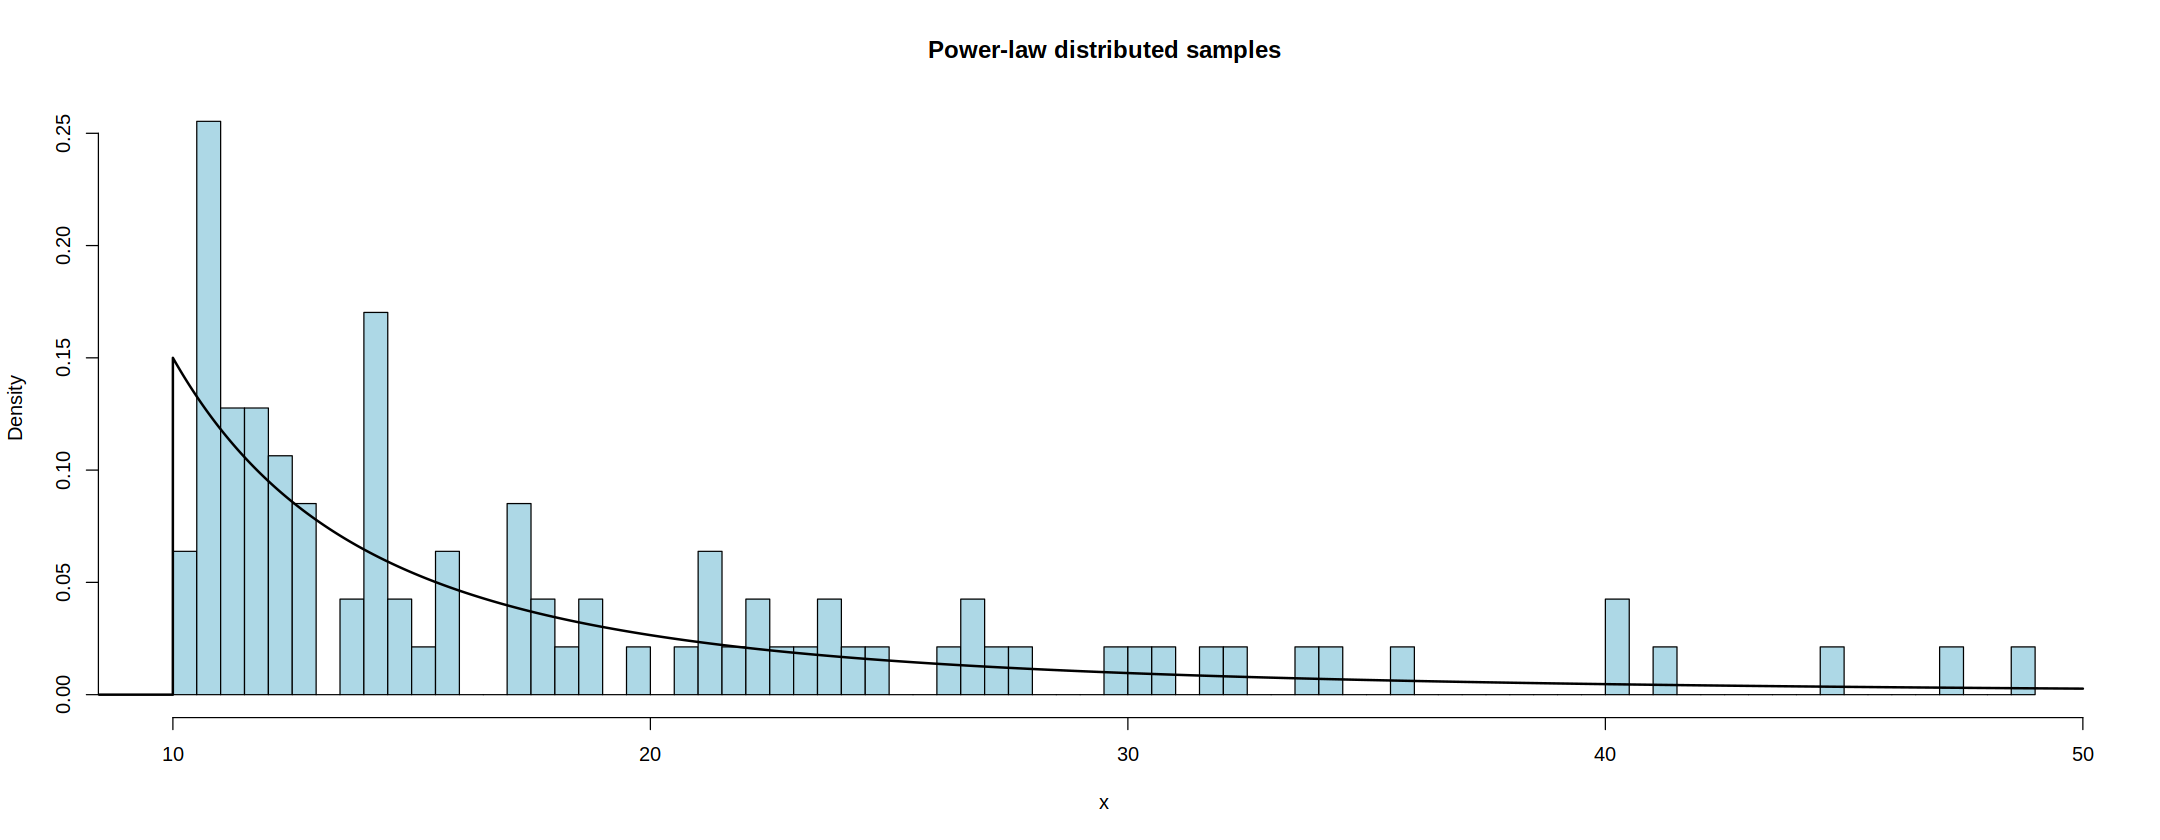

In [42]:
# parameters:
x_min <- 10   # x_min value
al <- 2.5     # alfa value
n <- 100    # nuumber of samples

# power law function:
power_law <- function(x, x_min, al){
    ifelse( x >= x_min, ( (al-1)/x_min )*( (x/x_min)^(-al) ), 0 ) }
x_ax <- seq(0,50, 0.001)
y_ax <- power_law(x_ax, x_min, al)

# inverse cdf:
z <- runif(n)
inverse_cdf <- function(z) {
    return( ( (1-z)/(x_min)^(al-1) )^(1/(1-al)) )
}
samples <- inverse_cdf(z)

# PLOT:
hist(samples[ samples<50 ], breaks=100, col='lightblue', main='Power-law distributed samples', xlab='x', freq=FALSE)
lines(x_ax, y_ax, lwd=2, col='black')

#### 2. Assuming $x_{min}$ fixed and $\alpha$ unknown, build JAGS models using the priors:
* alpha ∼ dunif(1.01, 10)
* alpha ∼ dnorm(2.5, 100)

We can use:
$$ \text{Pareto distribution} \quad p(x| \beta, c) = \beta c^{\beta} x^{-(\beta+1)} $$
where $\beta = \alpha-1$ and $c= x_{min}$.

In [57]:
# JAGS model definitions with different priors on the shape parameter
pl_model_1 <- "
model {
    shape ~ dunif(1.01, 10)
    for (j in 1:N) {
        obs[j] ~ dpar(shape, xmin)
    }
}"
pl_model_2 <- "
model {
    shape ~ dnorm(2.5, 100)
    for (j in 1:N) {
        obs[j] ~ dpar(shape, xmin)
    }
}"

# Store models and labels
model_defs <- list(pl_model_1, pl_model_2)
prior_labels <- c("shape ~ dunif(1.01, 10)", "shape ~ dnorm(2.5, 100)")

# Iterate over both models
for (idx in seq_along(model_defs)) {
    model_code <- model_defs[[idx]]
    prior_text <- prior_labels[idx]
    
    # Write model to file
    writeLines(model_code, con = "tmp_model.txt")
    
    # Data to pass to JAGS
    jags_data <- list(
        obs = samples,
        N = length(samples),
        xmin = x_min
    )
    
    # Initialize JAGS model
    jm <- jags.model(file = "tmp_model.txt", data = jags_data, n.chains = 3, quiet = TRUE)
    
    # Burn-in
    update(jm, n.iter = 1000)
    
    # Sample from posterior
    posterior <- coda.samples(jm, variable.names = "shape", n.iter = 10000)
    
    # Clean up
    unlink("tmp_model.txt")
    
    # Convert and summarize
    draws <- as.matrix(posterior)
    post_mean <- mean(draws)
    post_density <- density(draws)
    post_mode <- post_density$x[which.max(post_density$y)]
    credible_interval <- quantile(draws, probs = c(0.025, 0.975))
    
    # Display results
    cat(paste0(prior_text, "\n"))
    cat(sprintf("Posterior mean: %.4f\n", post_mean))
    cat(sprintf("Posterior mode: %.4f\n", post_mode))
    cat(sprintf("95%% credible interval: [%.4f, %.4f]\n\n", credible_interval[1], credible_interval[2]))
}


shape ~ dunif(1.01, 10)
Posterior mean: 1.5864
Posterior mode: 1.5623
95% credible interval: [1.2914, 1.9072]

shape ~ dnorm(2.5, 100)
Posterior mean: 2.3001
Posterior mode: 2.2998
95% credible interval: [2.1194, 2.4806]



#### 3. Run MCMC to get the posterior distribution. Evaluate the mean, the most probable value, the credibility interval at 95% level.

See point 2.

#### 4. Compare the Bayesian estimate for α with the one achieved in frequentist setting.

In [58]:
# Frequentist MLE estimate
alpha_mle <- function(x, x_min) {
  n <- length(x)
  1 + n / sum(log(x / x_min))
}

# Compute MLE from your samples
alpha_hat_mle <- alpha_mle(samples, x_min)

# Print MLE
cat(sprintf("Frequentist MLE of alpha: %.4f\n", alpha_hat_mle))


Frequentist MLE of alpha: 2.5729
